# Testing the runtime of different scores with different settings

In [14]:
import os
import scanpy as sc

dir = "../datasets_prepro/"

first = True
for file in os.listdir(dir):
    if file.endswith('.h5ad'):
        print(os.path.join(dir, file))
        adata = sc.read_h5ad(os.path.join(dir, file))
        print(adata.n_vars, adata.n_obs)
        print(len(set(adata.obs['leiden'])))



../datasets_prepro/GSM6592049_M2_prepro.h5ad
20390 2255
10
../datasets_prepro/GSM6592052_M5_prepro.h5ad
20910 4246
15
../datasets_prepro/GSM6592053_M6_prepro.h5ad
20764 2795
13
../datasets_prepro/GSM6592055_M8_prepro.h5ad
19918 3261
11
../datasets_prepro/GSM6592059_M13_prepro.h5ad
20854 4476
10


In [ ]:
dir_base = os.path.join('..', "outputs")
dir_params = ["prepro_defaults", "prepro_permsX10", "prepro_permsX20", "prepro_permsX100"]

files_per_dir = []
for dir_param in dir_params:
    dir = os.path.join(dir_base, dir_param)

    one_dir = []
    for file in os.listdir(dir):
        if file.endswith('.h5ad'):
            #print(os.path.join(dir, file))
            one_dir.append(os.path.join(dir, file))
    files_per_dir.append(one_dir)

for f in files_per_dir:
    print(f)

['..\\outputs\\prepro_defaults\\GSM6592049_M2_prepro_defaults.h5ad', '..\\outputs\\prepro_defaults\\GSM6592052_M5_prepro_defaults.h5ad', '..\\outputs\\prepro_defaults\\GSM6592053_M6_prepro_defaults.h5ad', '..\\outputs\\prepro_defaults\\GSM6592055_M8_prepro_defaults.h5ad', '..\\outputs\\prepro_defaults\\GSM6592059_M13_prepro_defaults.h5ad']
['..\\outputs\\prepro_permsX10\\GSM6592049_M2_prepro_permsX10.h5ad', '..\\outputs\\prepro_permsX10\\GSM6592052_M5_prepro_permsX10.h5ad', '..\\outputs\\prepro_permsX10\\GSM6592053_M6_prepro_permsX10.h5ad', '..\\outputs\\prepro_permsX10\\GSM6592055_M8_prepro_permsX10.h5ad', '..\\outputs\\prepro_permsX10\\GSM6592059_M13_prepro_permsX10.h5ad']
['..\\outputs\\prepro_permsX20\\GSM6592049_M2_prepro_permsX20.h5ad', '..\\outputs\\prepro_permsX20\\GSM6592052_M5_prepro_permsX20.h5ad', '..\\outputs\\prepro_permsX20\\GSM6592053_M6_prepro_permsX20.h5ad', '..\\outputs\\prepro_permsX20\\GSM6592055_M8_prepro_permsX20.h5ad', '..\\outputs\\prepro_permsX20\\GSM6592059_M

In [82]:
import pandas as pd
import itertools
import numpy as np


def calc_differences(files_per_dir, idx, mode, dir_params):
    # Load your AnnData objects
    adatas = [sc.read_h5ad(file[idx]) for file in files_per_dir]

    m = [i for i in range(len(adatas))]
    combis = set(itertools.combinations(m,2))

    morans = [pd.Series(adata.uns[mode][mode[-1]].values) for adata in adatas]
    morans_padj = [pd.Series(adata.uns[mode]["pval_norm_fdr_bh"].values) for adata in adatas]

    corr_s = np.zeros((len(m), len(m)))
    corr_p = np.zeros((len(m), len(m)))
    dist_s = np.zeros((len(m), len(m)))
    dist_p = np.zeros((len(m), len(m)))

    for a, b in combis:
        #print(dir_params[a], dir_params[b])
        corr_s[a, b] = morans[a].corr(morans[b])
        #print(corr_s[a, b])
        corr_p[a, b] = morans_padj[a].corr(morans_padj[b])
        #print(corr_p[a, b])
        dist_s[a, b] = np.sum(np.abs(morans[a] - morans[b]))
        #print(dist_s[a, b])
        dist_p[a, b] = np.sum(np.abs(morans_padj[a] - morans_padj[b]))
        #print(dist_p[a, b])

    print(dir_params)
    print(corr_s, "correlation of scores")
    print(corr_p, "correlation of padj")
    print(dist_s, "distance of scores")
    print(dist_p, "distance of padj")

In [83]:
for i in range(len(files_per_dir[0])):
    print(files_per_dir[0][i])
    print("Moran")
    calc_differences(files_per_dir, i, "moranI", dir_params)
    print("Geary")
    calc_differences(files_per_dir, i, "gearyC", dir_params)
    print()

..\outputs\prepro_defaults\GSM6592049_M2_prepro_defaults.h5ad
Moran
['prepro_defaults', 'prepro_permsX10', 'prepro_permsX20', 'prepro_permsX100']
[[0.         0.99998103 0.99998103 0.99998103]
 [0.         0.         1.         1.        ]
 [0.         0.         0.         1.        ]
 [0.         0.         0.         0.        ]] correlation of scores
[[0.         0.99994394 0.99994394 0.99994394]
 [0.         0.         1.         1.        ]
 [0.         0.         0.         1.        ]
 [0.         0.         0.         0.        ]] correlation of padj
[[0.         1.94873261 1.94873261 1.94873261]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]] distance of scores
[[ 0.         12.26487002 12.26487002 12.26487002]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]] distance of padj
Gear

In [69]:
import matplotlib.pyplot as plt

def plot_differences(files_per_dir, idx, mode, dir_params, i, j):
    # Load your AnnData objects
    adatas = [sc.read_h5ad(file[idx]) for file in files_per_dir]

    morans = [adata.uns[mode][mode[-1]].values for adata in adatas]
    morans_padj = [adata.uns[mode]["pval_norm_fdr_bh"].values for adata in adatas]

    max_val = max([max(m) for m in morans])

    plt.figure(figsize=(6,6))
    # Plot the diagonal y = x
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', zorder=1, label='Diagonal y=x')
    plt.scatter(x=morans[i], y=morans[j], zorder=2, alpha=0.3, edgecolors='darkblue')
    plt.xlabel(f"{mode} {dir_params[i]}")
    plt.ylabel(f"{mode} {dir_params[j]}")
    plt.title(f"Comparison of {mode} scores {files_per_dir[0][idx]}")
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.axvline(0, color='gray', linestyle='--', linewidth=1)
    plt.show()

    max_val = max([max(m) for m in morans_padj])

    plt.figure(figsize=(6,6))
    # Plot the diagonal y = x
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', zorder=1, label='Diagonal y=x')
    plt.scatter(x=morans_padj[i], y=morans_padj[j], zorder=2, alpha=0.3, edgecolors='darkblue')
    plt.xlabel(f"{mode} padj {dir_params[i]}")
    plt.ylabel(f"{mode} padj {dir_params[j]}")
    plt.title(f"Comparison of {mode} padj {files_per_dir[0][idx]}")
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.axvline(0, color='gray', linestyle='--', linewidth=1)
    plt.show()

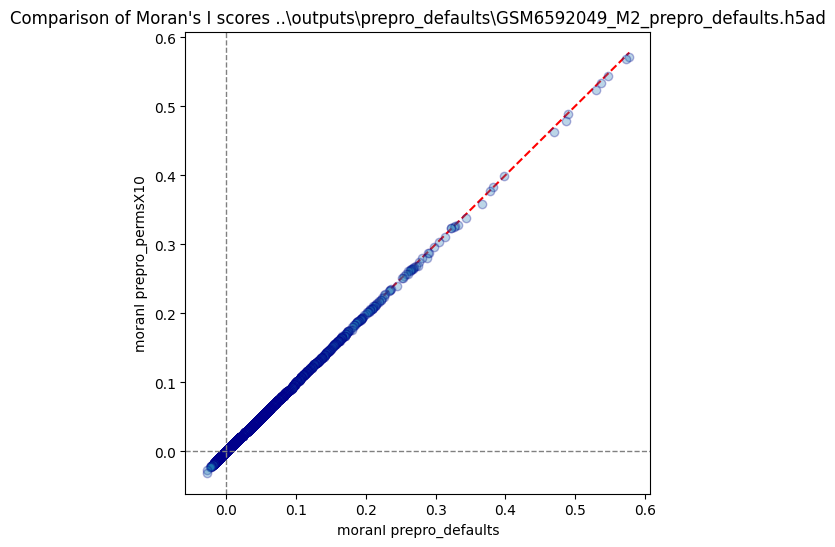

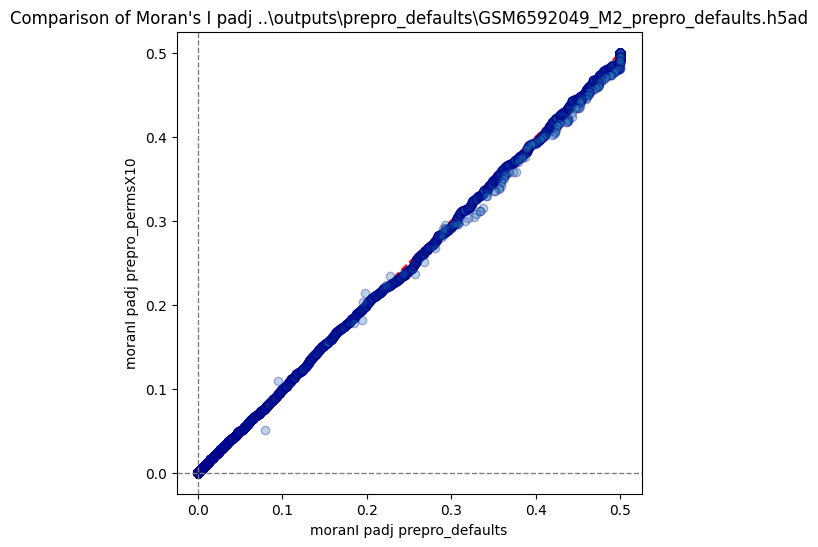

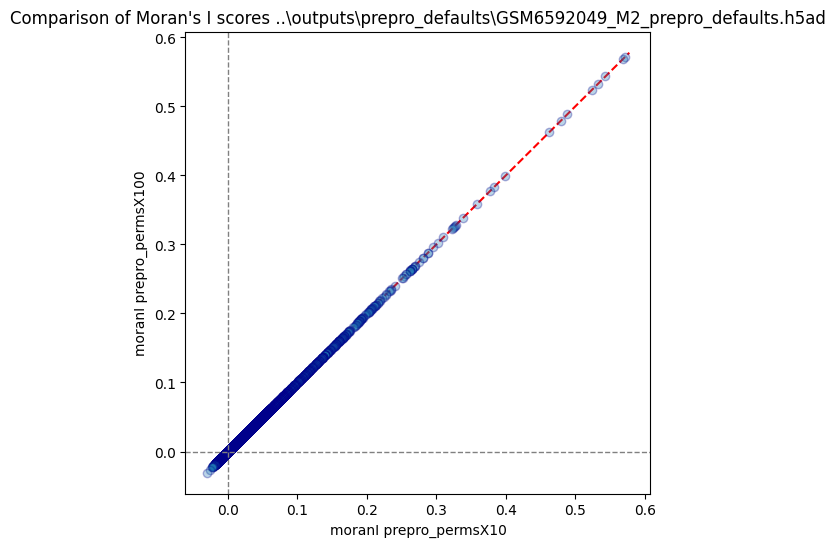

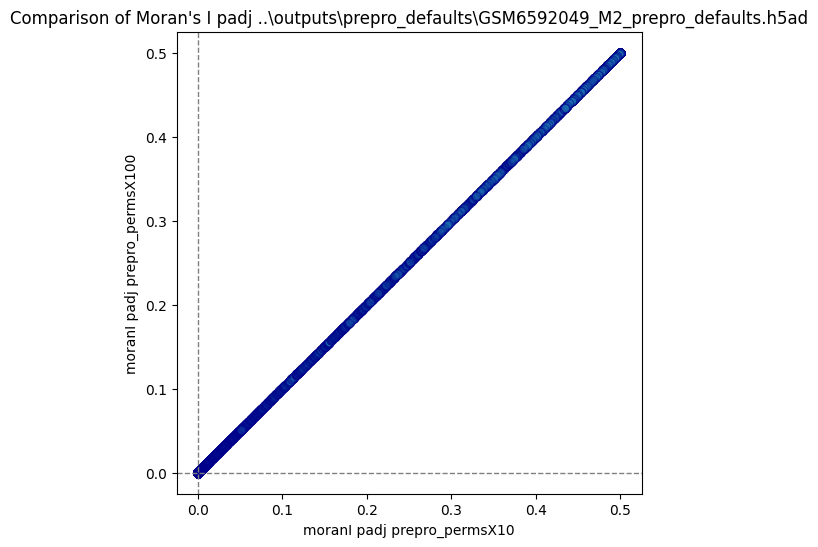

In [55]:
plot_differences(files_per_dir, 0, "moranI", dir_params, 0, 1)
plot_differences(files_per_dir, 0, "moranI", dir_params, 1, 3)

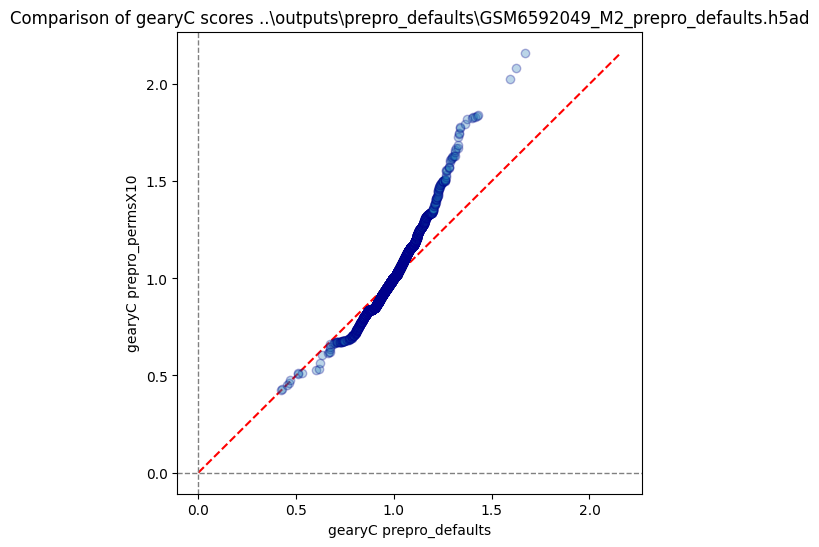

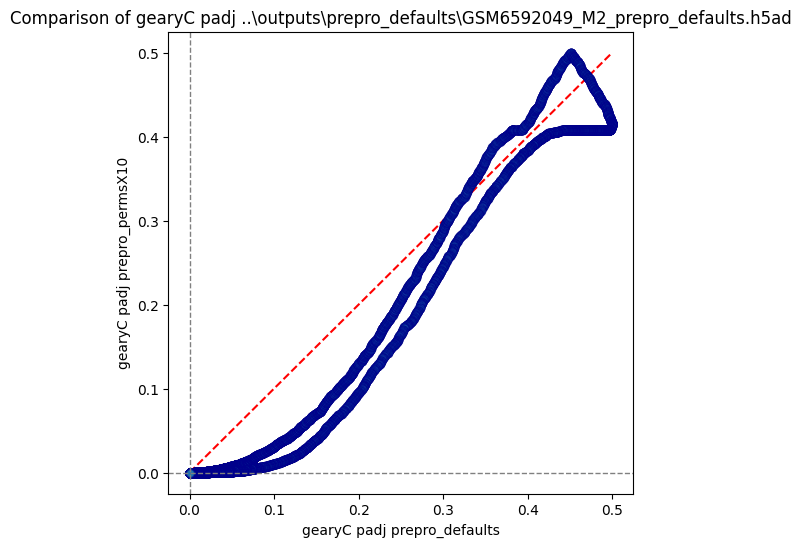

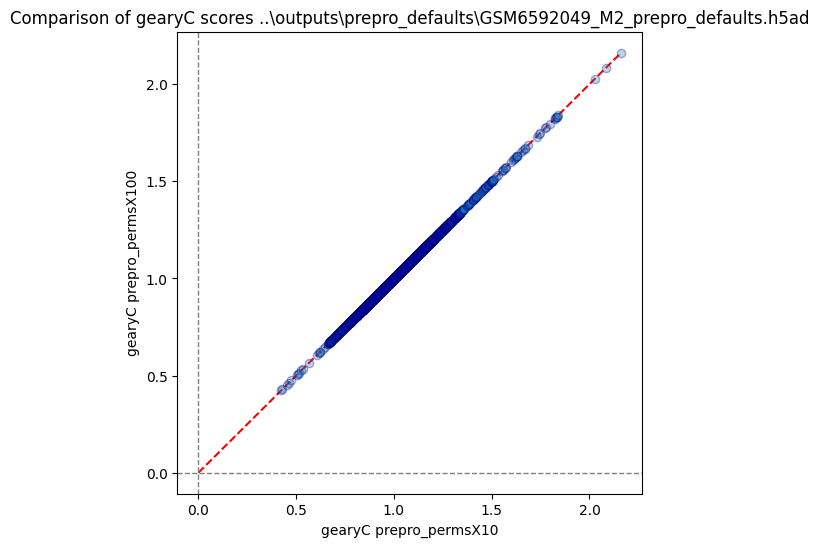

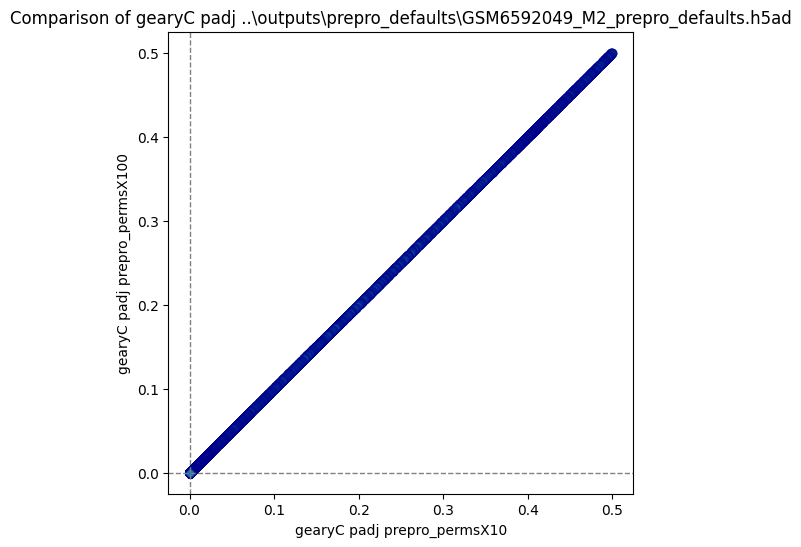

In [70]:
plot_differences(files_per_dir, 0, "gearyC", dir_params, 0, 1)
plot_differences(files_per_dir, 0, "gearyC", dir_params, 1, 3)

In [88]:
def calc_differences_co(files_per_dir, idx, dir_params):
    # Load your AnnData objects
    adatas = [sc.read_h5ad(file[idx]) for file in files_per_dir]

    m = [i for i in range(len(adatas))]
    combis = set(itertools.combinations(m,2))

    #print([adata.uns.get("leiden_co_occurrence") for adata in adatas])
    counts = [adata.uns["leiden_nhood_enrichment"].get('count') for adata in adatas]
    zscores = [adata.uns["leiden_nhood_enrichment"].get('zscore') for adata in adatas]
    
    #corr_s = np.zeros((len(m), len(m)))
    dist_c = np.zeros((len(m), len(m)))
    dist_z = np.zeros((len(m), len(m)))

    for a, b in combis:
        #print(dir_params[a], dir_params[b])
        #corr_s[a, b] = morans[a].corr(morans[b])
        #print(corr_s[a, b])
        dist_c[a, b] = np.mean(np.abs(counts[a] - counts[b]))
        #print("Mean Absolute Error:", dist_c[a, b])

        dist_z[a, b] = np.mean(np.abs(zscores[a] - zscores[b]))
        #print("Mean Absolute Error:", dist_z[a, b])

    print(dir_params)
    #print(corr_s, "correlation of scores")
    print(dist_c, "MAE of scores")
    print(dist_z, "MAE of zscores")

for i in range(len(files_per_dir[0])):
    print(files_per_dir[0][i])
    calc_differences_co(files_per_dir, i, dir_params)
    print()


..\outputs\prepro_defaults\GSM6592049_M2_prepro_defaults.h5ad
['prepro_defaults', 'prepro_permsX10', 'prepro_permsX20', 'prepro_permsX100']
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] MAE of scores
[[0.         0.20555549 0.1954802  0.18944031]
 [0.         0.         0.04582838 0.06386672]
 [0.         0.         0.         0.05482158]
 [0.         0.         0.         0.        ]] MAE of zscores

..\outputs\prepro_defaults\GSM6592052_M5_prepro_defaults.h5ad
['prepro_defaults', 'prepro_permsX10', 'prepro_permsX20', 'prepro_permsX100']
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] MAE of scores
[[0.         0.18744335 0.20289288 0.2123799 ]
 [0.         0.         0.05692785 0.07237285]
 [0.         0.         0.         0.04618293]
 [0.         0.         0.         0.        ]] MAE of zscores

..\outputs\prepro_defaults\GSM6592053_M6_prepro_defaults.h5ad
['prepro_defaults', 'prepro_permsX10', 'prepro_permsX20', 'prepro_permsX100']
[[0. 0. 0. 0.]
 [0. 

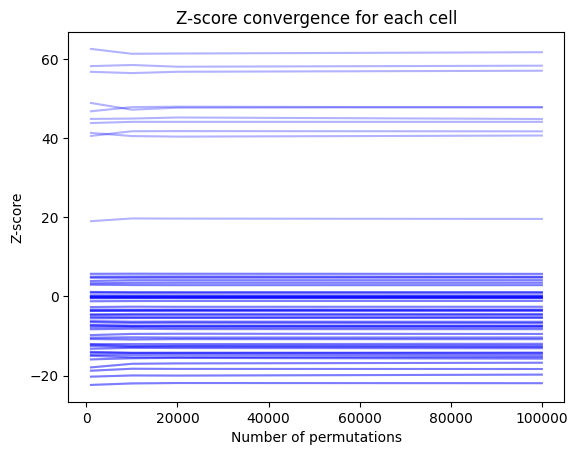

In [89]:
idx = 0

adatas = [sc.read_h5ad(file[idx]) for file in files_per_dir]

m = [i for i in range(len(adatas))]
combis = set(itertools.combinations(m,2))

zscores = [adata.uns["leiden_nhood_enrichment"].get('zscore') for adata in adatas]

zs_flattened = [Z.flatten() for Z in zscores]

import matplotlib.pyplot as plt
for i in range(len(zs_flattened[0])):
    values = [z[i] for z in zs_flattened]
    plt.plot([1000, 10000, 20000, 100000], values, alpha=0.3, color='blue')

plt.title("Z-score convergence for each cell")
plt.xlabel("Number of permutations")
plt.ylabel("Z-score")
plt.show()

In [ ]:

#adata.uns['moranI'].head()
#adata.uns['gearyC'].head()

# for 10 leiden clusters
#adata.uns['leiden_centrality_scores'].head() # 10x3
#adata.uns['leiden_nhood_enrichment'].keys()
# count: 10x10 array, zscore: 10x10 array
#adata.uns['leiden_co_occurrence'].keys()
# interval: 50x1, occ: 10x10x49   # (50 intervals)


(10, 10, 49)